<a href="https://colab.research.google.com/github/mdaminu2002-sketch/bank_fraud/blob/main/Agricultural_crops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/agricultural-crops-image-classification/Agricultural-crops/tomato/image (16).jpeg
/kaggle/input/agricultural-crops-image-classification/Agricultural-crops/tomato/image (4).jpeg
/kaggle/input/agricultural-crops-image-classification/Agricultural-crops/tomato/image (5).jpg
/kaggle/input/agricultural-crops-image-classification/Agricultural-crops/tomato/image (12).jpeg
/kaggle/input/agricultural-crops-image-classification/Agricultural-crops/tomato/image (7).jpg
/kaggle/input/agricultural-crops-image-classification/Agricultural-crops/tomato/image (6).jpg
/kaggle/input/agricultural-crops-image-classification/Agricultural-crops/tomato/image (9).jpg
/kaggle/input/agricultural-crops-image-classification/Agricultural-crops/tomato/image (1).jpeg
/kaggle/input/agricultural-crops-image-classification/Agricultural-crops/tomato/image (2).jpg
/kaggle/input/agricultural-crops-image-classification/Agricultural-crops/tomato/image (5).jpeg
/kaggle/input/agricultural-crops-image-classification

In [39]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mdwaquarazam/agricultural-crops-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'agricultural-crops-image-classification' dataset.
Path to dataset files: /kaggle/input/agricultural-crops-image-classification


In [40]:
print(os.listdir(path))

['Agricultural-crops']


In [41]:
inner_path = os.path.join(path, "Agricultural-crops")
print(os.listdir(inner_path))

['tomato', 'chilli', 'clove', 'pineapple', 'vigna-radiati(Mung)', 'Olive-tree', 'coconut', 'papaya', 'Tobacco-plant', 'jute', 'jowar', 'gram', 'tea', 'maize', 'wheat', 'soyabean', 'Pearl_millet(bajra)', 'Lemon', 'Fox_nut(Makhana)', 'mustard-oil', 'sugarcane', 'almond', 'Cucumber', 'sunflower', 'cotton', 'banana', 'Cherry', 'cardamom', 'rice', 'Coffee-plant']


In [42]:
cal = 0
for item in os.listdir(inner_path):

  full_path = os.path.join(inner_path, item)
  if os.path.isdir(full_path):
    count = len(os.listdir(full_path))
    print(f"{item} : {count}")
    cal += count
print(f"total data : {cal}")

tomato : 26
chilli : 23
clove : 30
pineapple : 25
vigna-radiati(Mung) : 27
Olive-tree : 30
coconut : 25
papaya : 23
Tobacco-plant : 33
jute : 23
jowar : 30
gram : 25
tea : 23
maize : 31
wheat : 31
soyabean : 30
Pearl_millet(bajra) : 39
Lemon : 28
Fox_nut(Makhana) : 23
mustard-oil : 28
sugarcane : 25
almond : 21
Cucumber : 31
sunflower : 24
cotton : 32
banana : 31
Cherry : 32
cardamom : 22
rice : 29
Coffee-plant : 29
total data : 829


In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import random_split, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms, datasets
import torchvision.models as models
#from torchvision.transforms import ToTensor
#from torchvision.models import resnet18

In [44]:
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(15),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])


train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



In [45]:
full_path = os.path.join(path, "Agricultural-crops")
dataset = ImageFolder(full_path, transform=train_transform)

print("Number of classes:", len(dataset.classes))
print("Class names:", dataset.classes)

Number of classes: 30
Class names: ['Cherry', 'Coffee-plant', 'Cucumber', 'Fox_nut(Makhana)', 'Lemon', 'Olive-tree', 'Pearl_millet(bajra)', 'Tobacco-plant', 'almond', 'banana', 'cardamom', 'chilli', 'clove', 'coconut', 'cotton', 'gram', 'jowar', 'jute', 'maize', 'mustard-oil', 'papaya', 'pineapple', 'rice', 'soyabean', 'sugarcane', 'sunflower', 'tea', 'tomato', 'vigna-radiati(Mung)', 'wheat']


In [46]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(dataset.classes))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Using device: {device}")
print(f"Final layer: {model.fc}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")


Using device: cuda
Final layer: Linear(in_features=512, out_features=30, bias=True)
Trainable parameters: 15390
Total parameters: 11191902


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [47]:
class TransformSubset(torch.utils.data.Dataset):
  def __init__(self, subset, transform):
    self.subset = subset
    self.transform = transform

  def __len__(self):
    return len(self.subset)

  def __getitem__(self, idx):
    images, labels = self.subset[idx]
    images = self.transform(images)
    return images, labels

In [48]:
full_dataset = ImageFolder(root=full_path)
print(len(full_dataset))

total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

train_dataset = TransformSubset(train_dataset, train_transform)
val_dataset = TransformSubset(val_dataset, val_test_transform)
test_dataset = TransformSubset(test_dataset, val_test_transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

829


In [49]:
print(f"train batch: {len(train_loader)}")
print(f"val batch: {len(val_loader)}")
print(f"test batch: {len(test_loader)}")

images, labels = next(iter(train_loader))
print("images shape:", images.shape)
print("labels shape:", labels.shape)



train batch: 19
val batch: 4
test batch: 4
images shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])


IndexError: index 9 is out of bounds for axis 0 with size 9

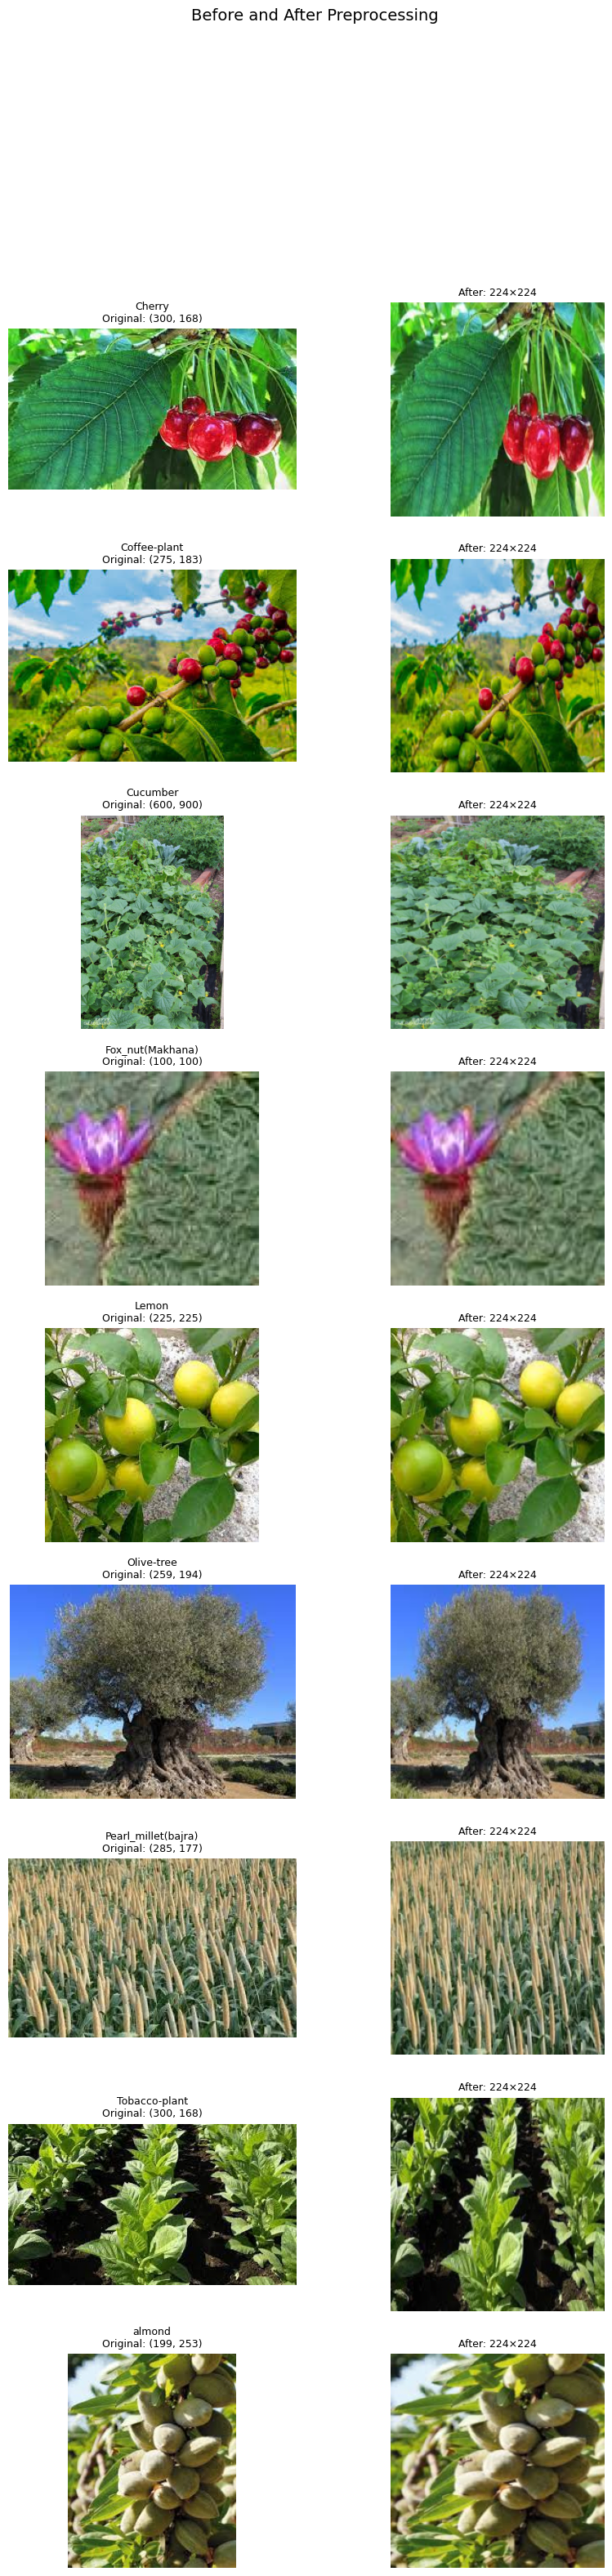

In [50]:
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import random
import os

# Pick one random image from each class
fig, axes = plt.subplots(9, 2, figsize=(10, 36))
fig.suptitle("Before and After Preprocessing", fontsize=14)

for idx, class_name in enumerate(full_dataset.classes):
    class_path = os.path.join(full_path, class_name)
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)

    # --- BEFORE ---
    original = Image.open(img_path).convert("RGB")
    axes[idx, 0].imshow(original)
    axes[idx, 0].set_title(f"{class_name}\nOriginal: {original.size}", fontsize=9)
    axes[idx, 0].axis("off")

    # --- AFTER ---
    processed = val_test_transform(original)  # use val transform (no augmentation)
    # unnormalize for display
    unnorm = processed.clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    unnorm = unnorm * std + mean
    unnorm = unnorm.clamp(0, 1).permute(1, 2, 0).numpy()

    axes[idx, 1].imshow(unnorm)
    axes[idx, 1].set_title(f"After: 224×224", fontsize=9)
    axes[idx, 1].axis("off")

plt.tight_layout()
plt.show()

In [51]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

epochs = 20
best_val_loss = float('inf')
best_model_path = "best_agric_model.pth"

total_train_loss, total_val_loss = [], []
total_train_acc, total_val_acc = [], []

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    # --- TRAINING ---
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total
    total_train_loss.append(avg_train_loss)
    total_train_acc.append(train_acc)

    # --- VALIDATION ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    total_val_loss.append(avg_val_loss)
    total_val_acc.append(val_acc)

    scheduler.step(avg_val_loss)

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)

    #if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1}/{epochs} | train loss: {avg_train_loss:.4f} | val loss: {avg_val_loss:.4f} | train acc: {train_acc*100:.2f}% | val acc: {val_acc*100:.2f}%")

print("Training complete!")

Epoch 1/20
Epoch 1/20 | train loss: 3.4422 | val loss: 3.2516 | train acc: 4.83% | val acc: 12.10%
Epoch 2/20
Epoch 2/20 | train loss: 3.0171 | val loss: 2.8956 | train acc: 18.28% | val acc: 22.58%
Epoch 3/20
Epoch 3/20 | train loss: 2.7038 | val loss: 2.7195 | train acc: 30.34% | val acc: 24.19%
Epoch 4/20
Epoch 4/20 | train loss: 2.4516 | val loss: 2.5286 | train acc: 40.86% | val acc: 31.45%
Epoch 5/20
Epoch 5/20 | train loss: 2.2802 | val loss: 2.3570 | train acc: 44.31% | val acc: 33.06%
Epoch 6/20
Epoch 6/20 | train loss: 2.1239 | val loss: 2.2393 | train acc: 52.76% | val acc: 41.13%
Epoch 7/20
Epoch 7/20 | train loss: 1.9416 | val loss: 2.1272 | train acc: 57.24% | val acc: 41.94%
Epoch 8/20
Epoch 8/20 | train loss: 1.8702 | val loss: 2.0138 | train acc: 58.97% | val acc: 47.58%
Epoch 9/20
Epoch 9/20 | train loss: 1.7872 | val loss: 1.9569 | train acc: 60.00% | val acc: 46.77%
Epoch 10/20
Epoch 10/20 | train loss: 1.6545 | val loss: 1.9248 | train acc: 63.45% | val acc: 45.97%

In [52]:
# Load your best saved weights first
model.load_state_dict(torch.load(best_model_path))

# Unfreeze ALL layers
for param in model.parameters():
    param.requires_grad = True

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

# Use a much lower LR to avoid destroying pretrained weights
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# Reset tracking lists
total_train_loss, total_val_loss = [], []
total_train_acc, total_val_acc = [], []
best_val_loss = float('inf')
best_model_agric_path = "best_agric_model_finetuned.pth"

epochs = 20

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    # --- TRAINING ---
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total
    total_train_loss.append(avg_train_loss)
    total_train_acc.append(train_acc)

    # --- VALIDATION ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    total_val_loss.append(avg_val_loss)
    total_val_acc.append(val_acc)

    scheduler.step(avg_val_loss)

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_agric_path)

    #if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1}/{epochs} | train loss: {avg_train_loss:.4f} | val loss: {avg_val_loss:.4f} | train acc: {train_acc*100:.2f}% | val acc: {val_acc*100:.2f}%")

print("Training complete!")

Trainable parameters: 11191902
Epoch 1/20
Epoch 1/20 | train loss: 1.0096 | val loss: 1.2436 | train acc: 74.66% | val acc: 62.10%
Epoch 2/20
Epoch 2/20 | train loss: 0.7646 | val loss: 1.0680 | train acc: 81.03% | val acc: 67.74%
Epoch 3/20
Epoch 3/20 | train loss: 0.6332 | val loss: 0.9276 | train acc: 85.69% | val acc: 70.97%
Epoch 4/20
Epoch 4/20 | train loss: 0.4967 | val loss: 1.0281 | train acc: 89.31% | val acc: 67.74%
Epoch 5/20
Epoch 5/20 | train loss: 0.4193 | val loss: 0.8536 | train acc: 90.00% | val acc: 72.58%
Epoch 6/20
Epoch 6/20 | train loss: 0.3747 | val loss: 0.8365 | train acc: 93.28% | val acc: 70.16%
Epoch 7/20
Epoch 7/20 | train loss: 0.2782 | val loss: 0.8487 | train acc: 94.14% | val acc: 73.39%
Epoch 8/20
Epoch 8/20 | train loss: 0.2400 | val loss: 0.9286 | train acc: 96.03% | val acc: 70.16%
Epoch 9/20
Epoch 9/20 | train loss: 0.1823 | val loss: 0.8260 | train acc: 97.41% | val acc: 74.19%
Epoch 10/20
Epoch 10/20 | train loss: 0.2241 | val loss: 0.8306 | tra

In [53]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.load_state_dict(torch.load("best_agric_model_finetuned.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

print(classification_report(
    all_labels, all_preds,
    target_names=full_dataset.classes))
print(confusion_matrix(all_labels, all_preds))

                     precision    recall  f1-score   support

             Cherry       1.00      1.00      1.00         8
       Coffee-plant       0.80      0.67      0.73         6
           Cucumber       1.00      0.71      0.83         7
   Fox_nut(Makhana)       1.00      1.00      1.00         1
              Lemon       0.80      0.57      0.67         7
         Olive-tree       0.17      0.50      0.25         2
Pearl_millet(bajra)       1.00      1.00      1.00         4
      Tobacco-plant       1.00      0.50      0.67         4
             almond       0.67      0.67      0.67         3
             banana       1.00      0.75      0.86         4
           cardamom       1.00      1.00      1.00         1
             chilli       1.00      1.00      1.00         1
              clove       0.60      0.50      0.55         6
            coconut       1.00      1.00      1.00         3
             cotton       0.75      0.75      0.75         4
               gram    